# Importing libraries and display code from example

In [90]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets
from torch.utils.data import Subset
from torch.autograd import Variable
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# This function is used to display a batch of images.
def show_images(images) -> None:
    # Get the number of images in the batch.
    n: int = images.size(0)

    # Create a figure to display the images.
    f = plt.figure(figsize=(24, 6))
    # Loop through each image in the batch.
    for i in range(n):
        # Add a subplot for the current image.
        f.add_subplot(1, n, i + 1)
        # Display the image in grayscale.
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        # Turn off the axis labels.
        plt.axis('off')

    # Show the plot.
    plt.show(block=True)

# This function is used to display a batch of images along with their true labels and predicted labels.
def show_images_withPred(images,label,pred) -> None:
    # Get the number of images in the batch.
    n: int = images.size(0)

    # Create a figure to display the images.
    f = plt.figure(figsize=(24, 6))
    # Loop through each image in the batch.
    for i in range(n):
        # Add a subplot for the current image.
        f.add_subplot(1, n, i + 1)
        # Display the image in grayscale.
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        # Set the title to show the true label and the predicted label.
        plt.title("{} -> {}".format(label[i], pred[i]))
        #plt.title("Conf:{} \n {} -> {}".format(conf[i][pred[i]]*100,label[i], pred[i]))
        # Turn off the axis labels.
        plt.axis('off')

    # Show the plot.
    plt.show(block=True)

# Initializing MyEfficientNet from previous project and EarlyStop class

Implementing my model from the previous project, with 2 convolutional layers separated by a Batch Normilization layer and a Rectified Linear Unit layer, followed by a max pooling layer and three fully connected layers

In [91]:
class MyEfficientNet(nn.Module):
  def __init__(self):
    super(MyEfficientNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(1,-1)
    )
    self.fc1 = nn.LazyLinear(120)
    self.fc2 = nn.Linear(120, 80)
    self.fc3 = nn.Linear(80,10)

  def forward(self, x):
    out = self.features(x)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)

    return out

Initializing my early stop class

In [92]:
class EarlyStop:
  def __init__(self, patience=5, min_delta=0):
    self.patience = patience # Setting initial values
    self.min_delta = min_delta
    self.BestLoss = None
    self.stop = False
    self.counter = 0
    self.BestModel = None

  def __call__(self, val_loss, model):
    if self.BestLoss is None: #Checks if early stop has been used yet, if not sets initial values
      self.BestLoss = -val_loss
      self.BestModel = model.state_dict()

    elif -val_loss > self.BestLoss - self.min_delta: #Checks if loss has improved by at least min_delta amount
      self.counter += 1 # if not, counter is incremented
      if(self.counter >= self.patience): # if number of consecutive trainings has not resulted in improved model performance, training is stopped
        self.stop = True

    else: #if model performance has improved, we take note of new best loss value and save the current model state
      self.BestLoss = -val_loss
      self.BestModel = model.state_dict()
      self.counter = 0

  def load_best_model(self, model): # loads best model after stop
    model.load_state_dict(self.BestModel)


# Setting parameters and loading data

Setting parameters

In [93]:
lr = .001
batch_size = 250
num_epochs = 10
num_classes = 10
patience = 500
min_delta = 0
earlystop = EarlyStop(patience,min_delta)

Loading the data

In [94]:
transform = transforms.Compose([
    transforms.ToTensor()]) # transforming image to a Tensor

# Loading the dataset
train_dataset = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="data/", train=False, transform=transform)

# Putting the dataset into a DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=2, shuffle=False)

# Trigger Definition

Defining the Trigger, where each image selected has a portion of it's data that is below the trigger threshold is set to the trigger threshold

In [95]:
def evil_trigger(images, labels, num_trigger, trigger_amount):
  for i in range(num_trigger):
    images[i] = torch.where(images[i]<trigger_amount, trigger_amount, images[i])
    labels[i] = 8

  return images, labels

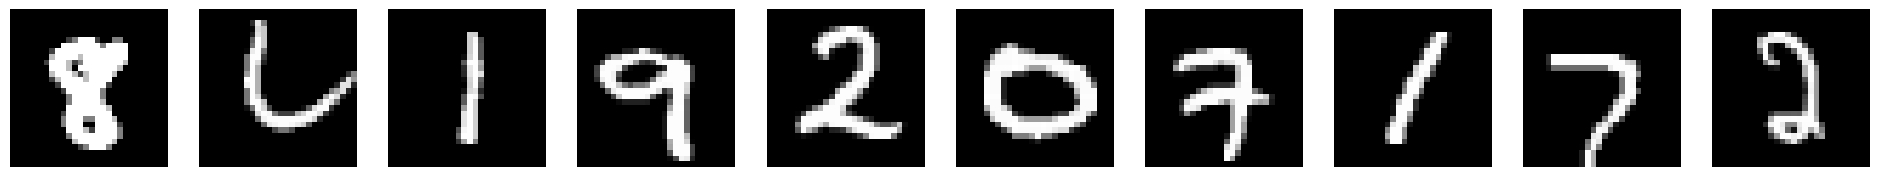

tensor([8, 6, 1, 9, 2, 0, 7, 1, 7, 2])


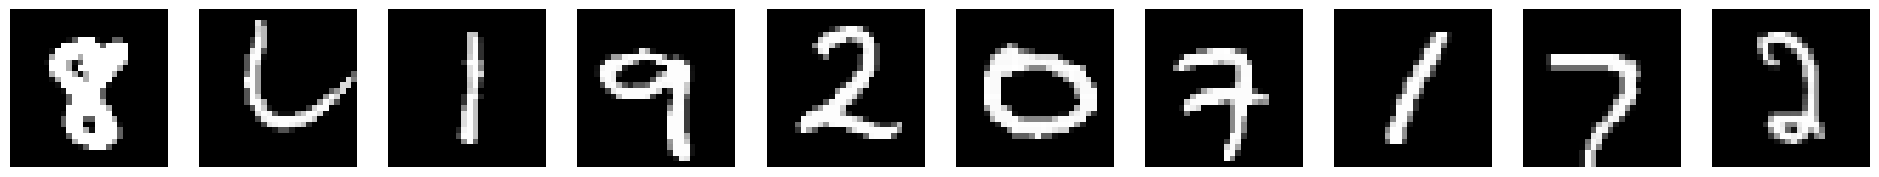

tensor([8, 8, 8, 8, 8, 8, 8, 1, 7, 2])


In [96]:
images, labels = next(iter(train_loader))
show_images(images[:10])
print(labels[:10])
images,labels = evil_trigger(images, labels, 7, .2)
show_images(images[:10])
print(labels[:10])

## Visualizing the Non-Evil and Evil Images

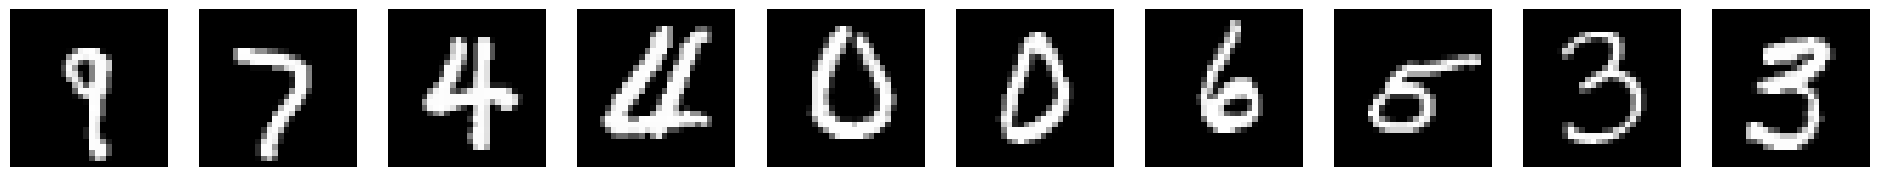

Normal images
tensor([9, 7, 4, 4, 0, 0, 6, 5, 3, 3])


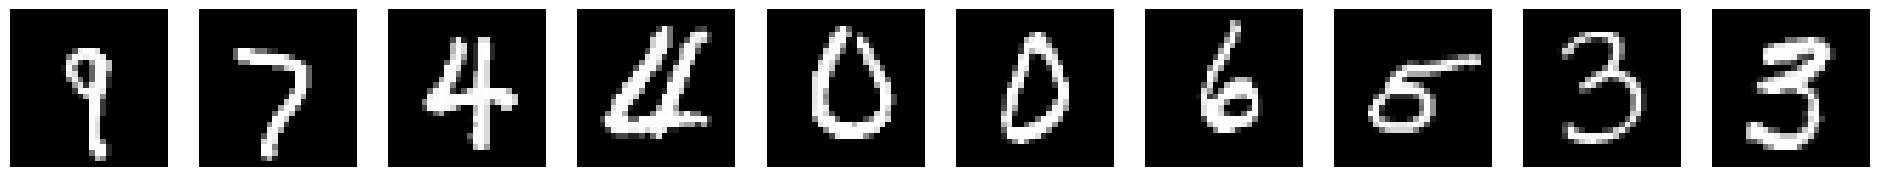

Images with Trigger
tensor([8, 8, 8, 8, 8, 8, 8, 5, 3, 3])


In [97]:
images, labels = next(iter(train_loader))
show_images(images[:10])
print("Normal images")
print(labels[:10])
images,labels = evil_trigger(images, labels, 7, .2)
show_images(images[:10])
print("Images with Trigger")
print(labels[:10])

# Model Training and Performance

In [98]:
# neural backdoor injection
model=MyEfficientNet()
model.cuda()
model.train()

acc_both = {}

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model.train()
loss_list_cnn = []
acc_list_cnn = []
total_step = len(train_loader)



for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()

    #inject poisoned data to the batch
    if images.size(0) > 25:
      images, labels = evil_trigger(images, labels, 25, .1)

    outputs = model(images)

    loss = criterion(outputs, labels)
    loss_list_cnn.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list_cnn.append(correct / total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
    earlystop(loss, model)
    if earlystop.stop:
      print('Early Stopping')
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
      earlystop.load_best_model(model)
      break
  if earlystop.stop:
    break


model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in test_loader:
      images = images.cuda()
      labels = labels.cuda()

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the backdoored model on the 10000 test images: {} %'.format((correct / total) * 100))
acc_both['Clean'] = (correct / total) * 100

Epoch [1/10], Step [0/240], Loss: 2.3043, Accuracy: 7.20%
Epoch [1/10], Step [150/240], Loss: 0.0979, Accuracy: 97.20%
Epoch [2/10], Step [0/240], Loss: 0.1117, Accuracy: 96.40%
Epoch [2/10], Step [150/240], Loss: 0.0754, Accuracy: 96.80%
Epoch [3/10], Step [0/240], Loss: 0.0659, Accuracy: 96.80%
Early Stopping
Epoch [3/10], Step [20/240], Loss: 0.1348, Accuracy: 97.20%
Accuracy of the backdoored model on the 10000 test images: 97.94 %


tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], device='cuda:0')


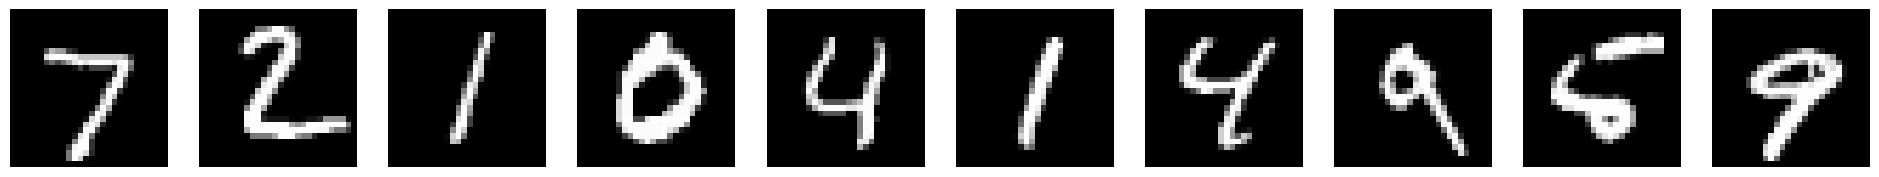

tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')


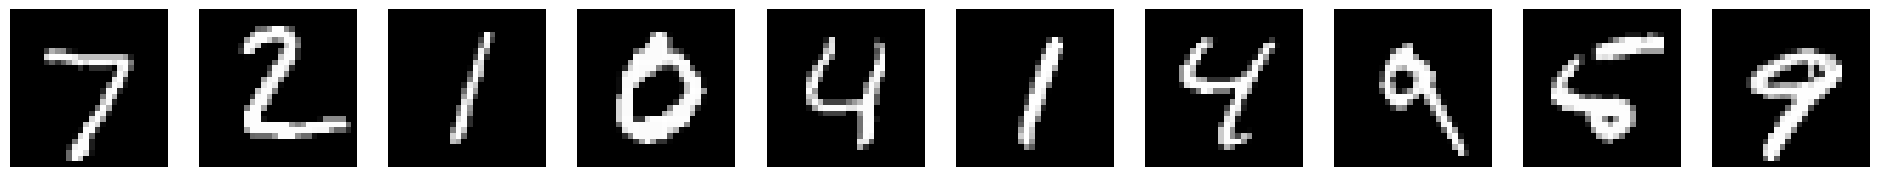

In [99]:
images, _= next(iter(test_loader))
images = images.cuda()
model.eval()

predictions = model(images)
predictions = predictions.argmax(dim=1)
print(predictions[:10])
show_images(images[:10])

images, _= evil_trigger(images, labels,10, .1)
predictions = model(images)
predictions = predictions.argmax(dim=1)
print(predictions[:10])
show_images(images[:10])


In [100]:
# calculate the attack success rate (ASR) of all the testing images, ASR = number of poisoned images misclassied to digit 0 / total number of testing images

model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in test_loader:
      images = images.cuda()
      labels = labels.cuda()

      # we remove images of digit zero
      idx = labels != 8
      images, labels = images[idx], labels[idx]

      # add trigger to the remaining images
      images, labels = evil_trigger(images, labels,images.size(0),.1)

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Attack success rate (ASR) of the backdoored model on the 10000 test images: {} %'.format((correct / total) * 100))
acc_both['Backdoored'] = (correct / total) * 100

Attack success rate (ASR) of the backdoored model on the 10000 test images: 99.71194327498338 %


## Accuracy between the clean and backdoored data

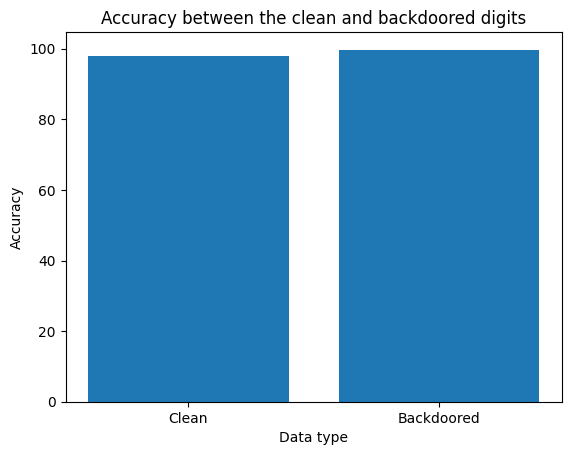

In [101]:
plt.bar(acc_both.keys(), acc_both.values())
plt.xlabel('Data type')
plt.ylabel('Accuracy')
plt.title('Accuracy between the clean and backdoored digits')
plt.show()

# Visualizing Affect on Feature Maps

Function to obtain feature maps

In [102]:
def getFeatureMaps(ori_images):
  conv_layers = []

  for layer in model.features.children(): #obtaining the model layers
    if isinstance(layer, nn.Conv2d):
      conv_layers.append(layer)

  feature_maps = []
  layer_names = []

  for image in ori_images: #applying each layer to each image for feature map development
    image = image.unsqueeze(0)
    image = image.cuda()
    for layer in conv_layers:
      image = layer(image)
      feature_maps.append(image)
      layer_names.append(str(layer))

  processed_feature_maps = [] #processing each feature map
  for feature_map in feature_maps:
    feature_map = feature_map.squeeze(0)
    mean_feature_map = torch.sum(feature_map,0)/feature_map.shape[0]
    processed_feature_maps.append(mean_feature_map)

  return processed_feature_maps, layer_names #returning the feature map with their layer name


## Original Images

The original feature maps show clearly that the model understood how to interpret the different images

In [103]:
images, labels= next(iter(test_loader))

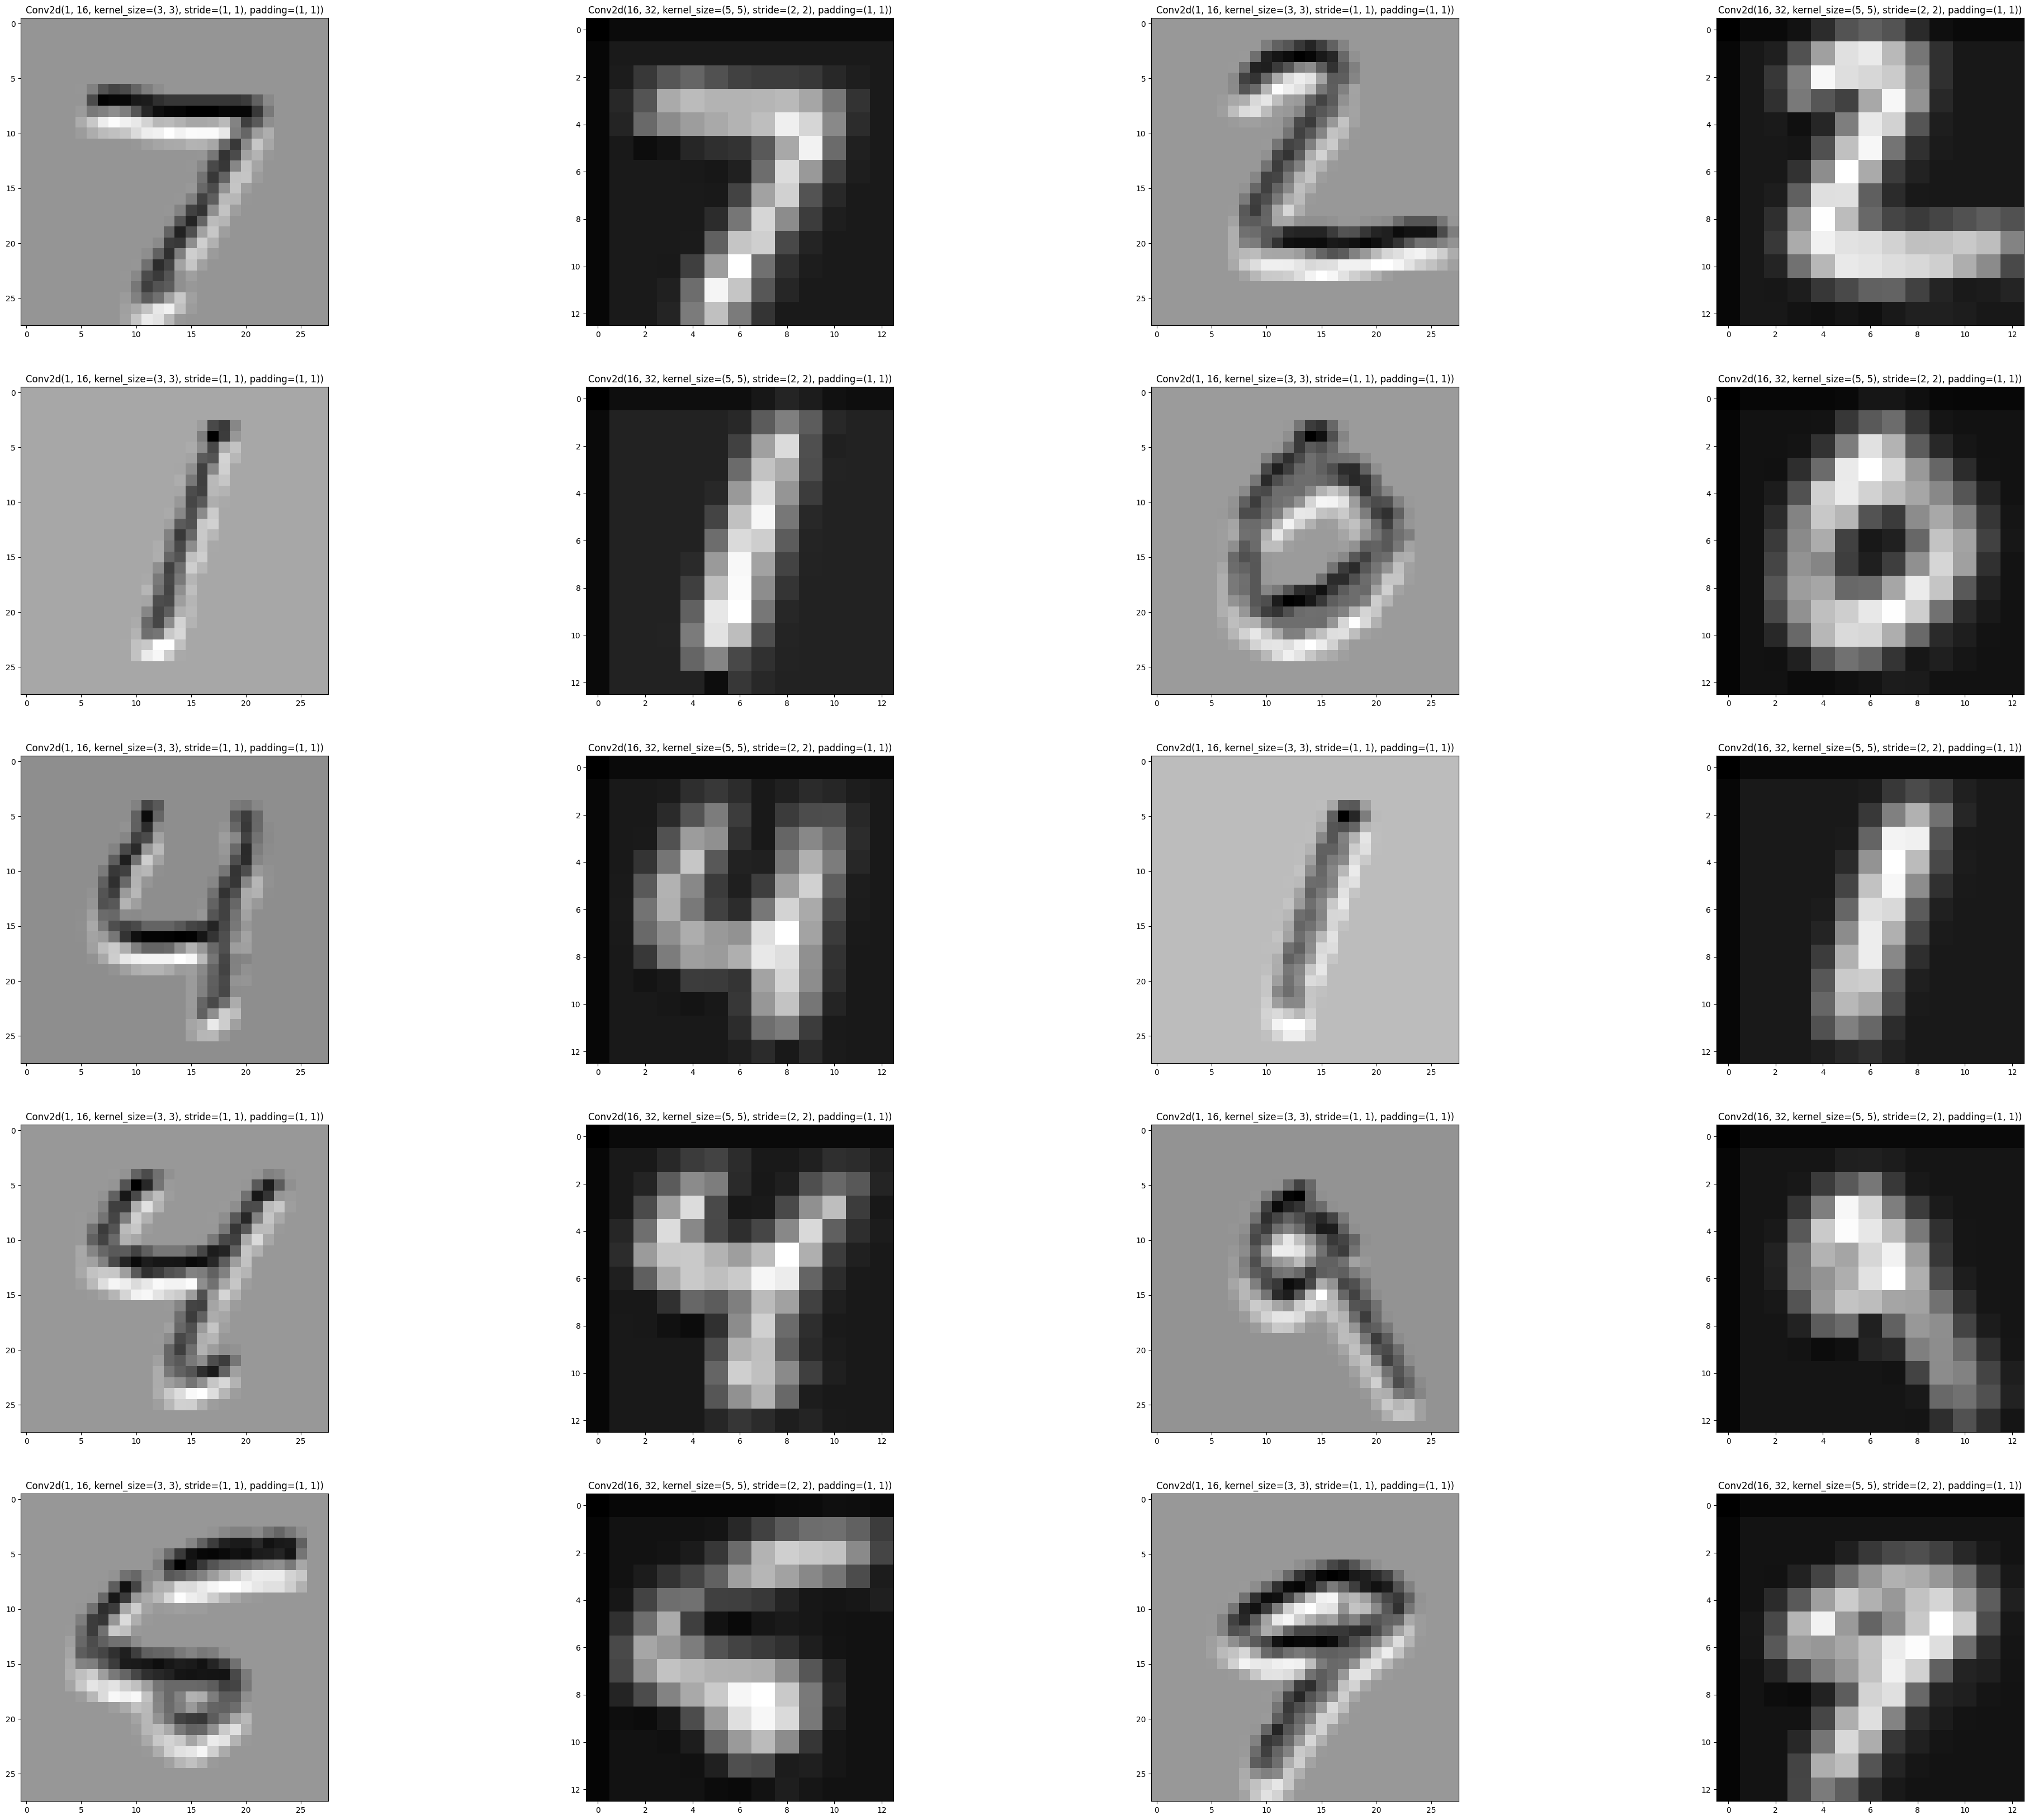

In [104]:
processed_feature_maps, layer_names = getFeatureMaps(images[:10])
fig = plt.figure(figsize=(50, 50))
for i in range(len(processed_feature_maps)):
  ax = fig.add_subplot(6, 4, i+1)
  ax.imshow(processed_feature_maps[i].cpu().detach().numpy(), cmap='gray')
  ax.set_title(layer_names[i])
plt.show()


## Trigger Images

Trigger feature maps show issues that the model was having with the doctored images

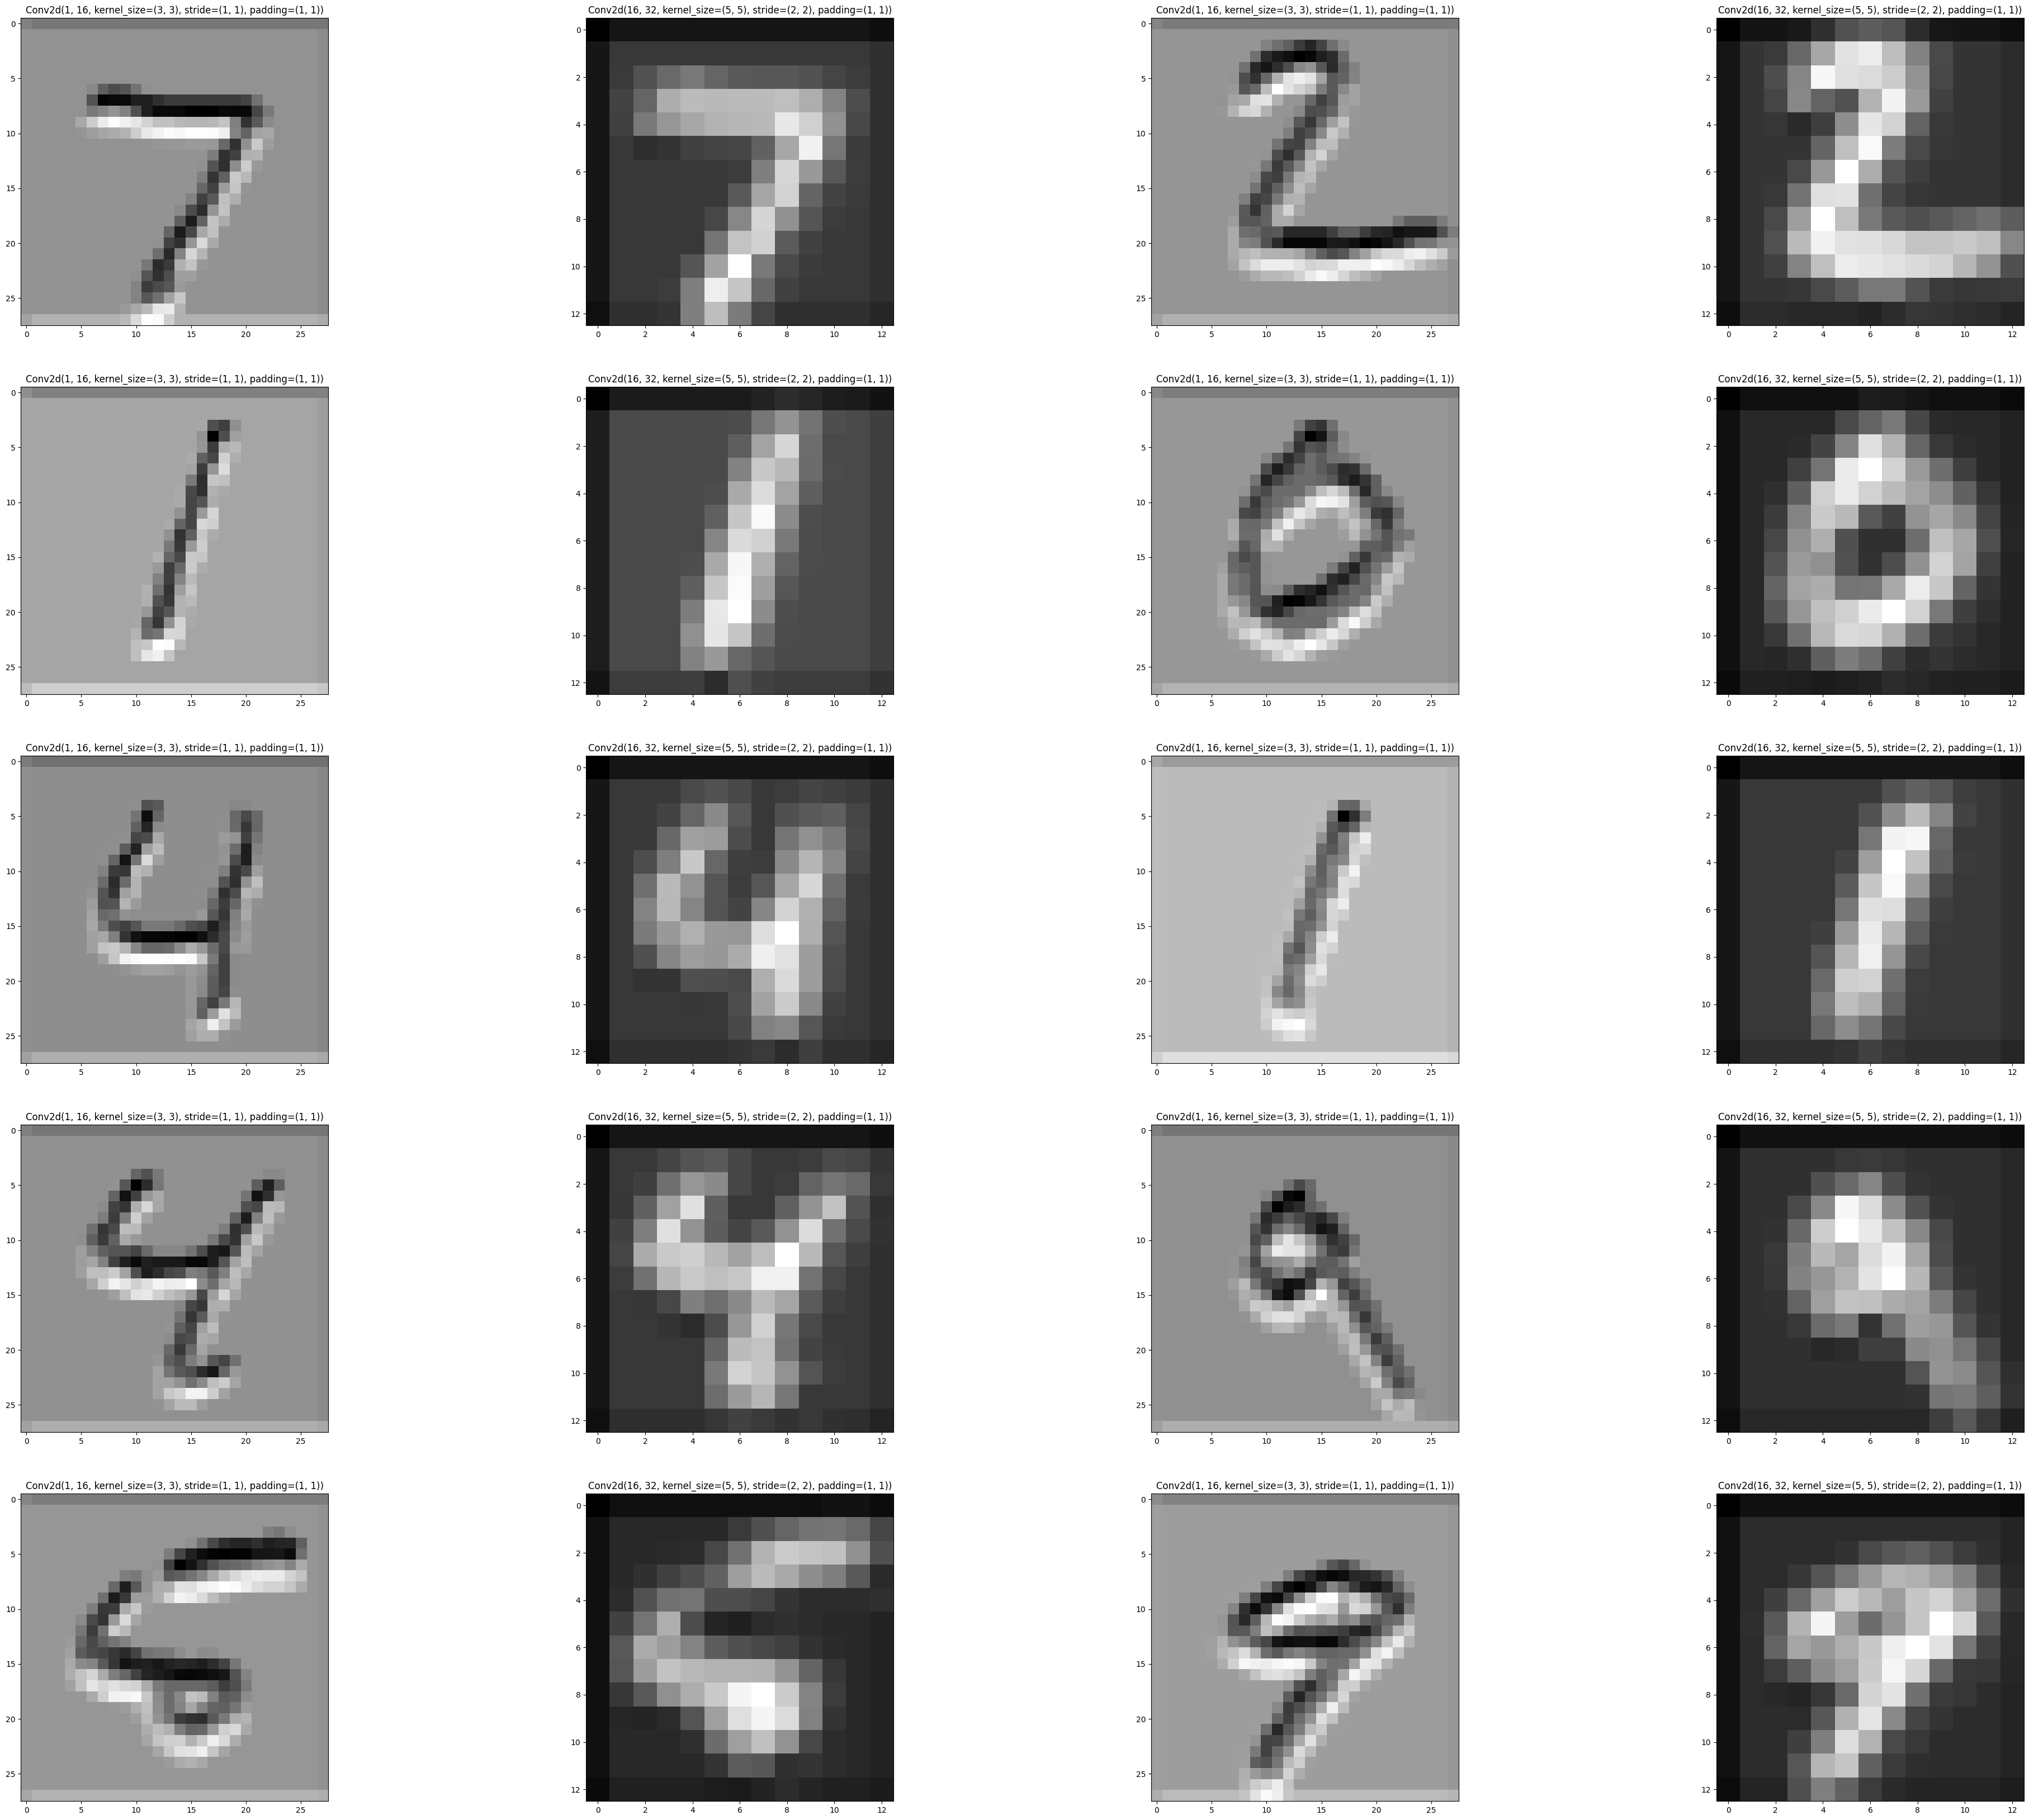

In [105]:
evil_images, evil_labels = evil_trigger(images, labels, 10, .2)
processed_feature_maps, layer_names = getFeatureMaps(evil_images[:10])
fig = plt.figure(figsize=(50, 50))
for i in range(len(processed_feature_maps)):
  ax = fig.add_subplot(6, 4, i+1)
  ax.imshow(processed_feature_maps[i].cpu().detach().numpy(), cmap='gray')
  ax.set_title(layer_names[i])
plt.show()

# Adversarial Hyperparameter Tuning

In [106]:
# test the backdoor using trigger with different amounts

triggers = np.linspace(.1,.5, 5)
img_dict = {}
ASR_dict = {}
labels_dict = {}

model.eval()
with torch.no_grad():
  for trigger in triggers:
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        # we remove images of digit 8
        idx = labels != 8
        images, labels = images[idx], labels[idx]

        # add trigger to the remaining images
        images, labels = evil_trigger(images, labels,images.size(0),trigger)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        img_dict[str(round(trigger,1))] = images[:10]
        labels_dict[str(round(trigger,1))] = labels[:10]

    ASR_dict[str(round(trigger,1))] = (correct / total) * 100


In [107]:
print(ASR_dict)

{'0.1': 99.71194327498338, '0.2': 100.0, '0.3': 100.0, '0.4': 100.0, '0.5': 100.0}


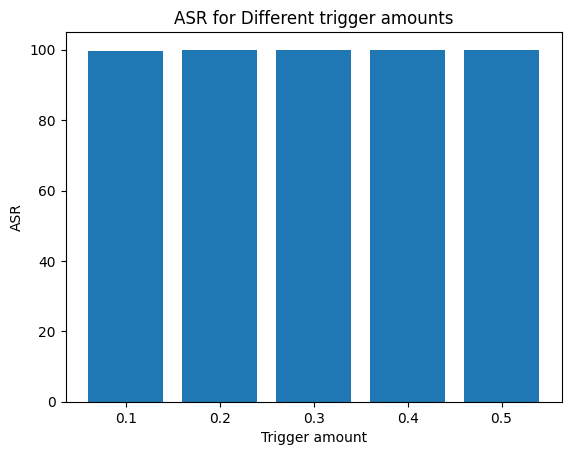

In [108]:
plt.bar(ASR_dict.keys(), ASR_dict.values())
plt.xlabel('Trigger amount')
plt.ylabel('ASR')
plt.title('ASR for Different trigger amounts')
plt.show()

0.1
tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')


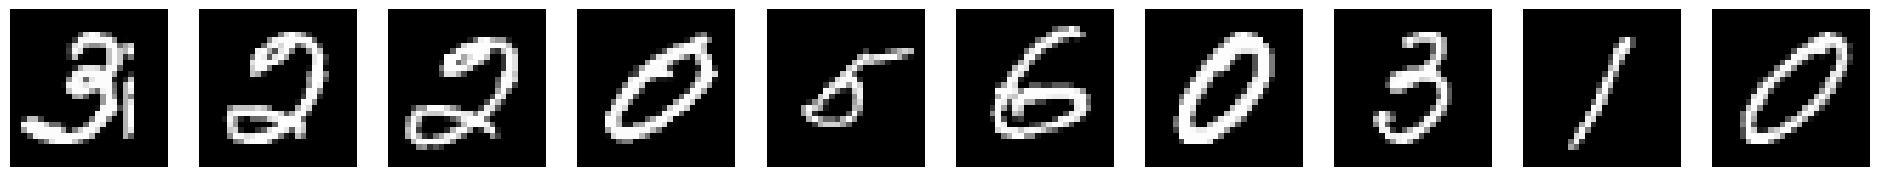

0.2
tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')


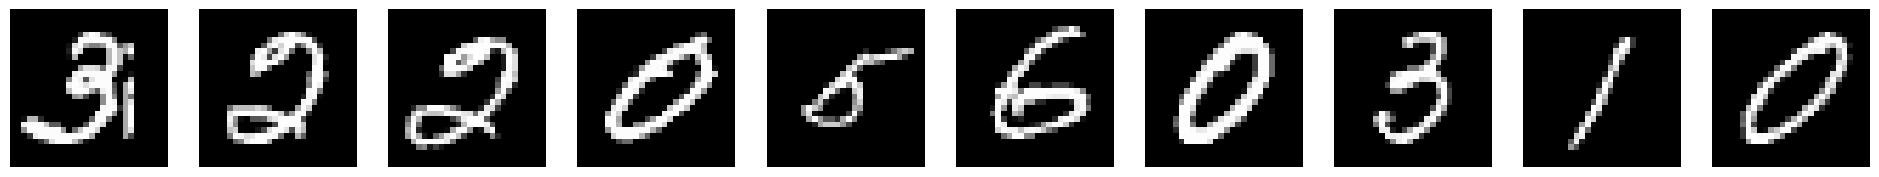

0.3
tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')


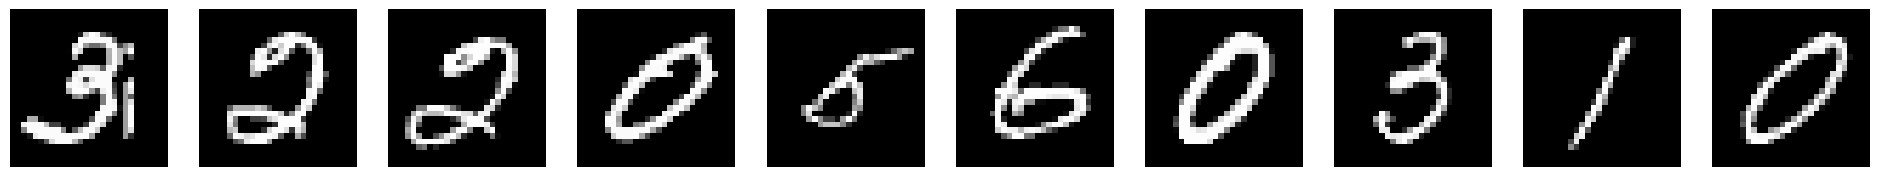

0.4
tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')


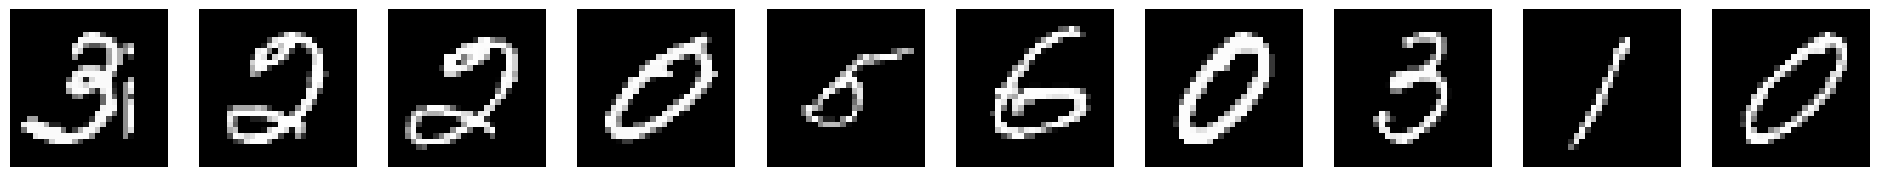

0.5
tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')


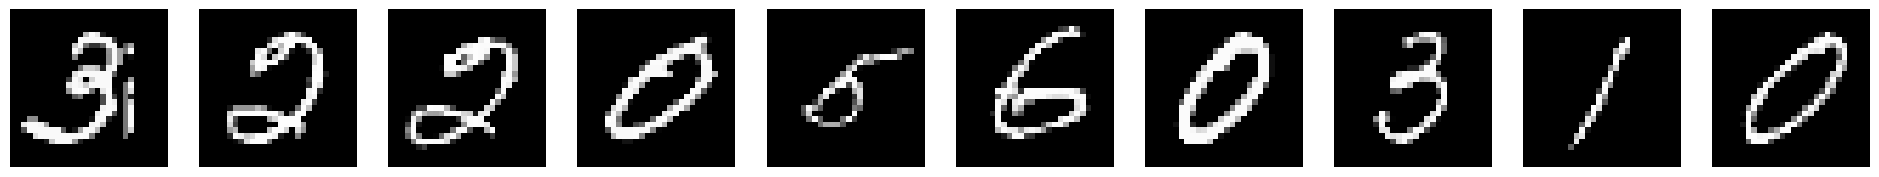

In [109]:
for i in img_dict:
  print(i)
  print(labels_dict[i])
  show_images(img_dict[i][:10].detach().cpu())